Original columns: ['種類', '負載', '效率']
Shape: (1456, 3)
  種類   負載     效率
0  B  0.5  55.67
1  B  0.6  59.47
2  B  0.7  63.03
3  B  0.8  65.97
4  B  0.9  68.08

Missing values (after coercion):
 type          0
load          0
efficiency    0
dtype: int64

Ranges:
load min/max: 0.5 3.0
efficiency min/max: 34.22 87.89

Counts by type:
 type
A     26
B    104
C     26
D    104
E    104
F     26
G    104
H    312
I     26
J    208
K    416
Name: count, dtype: int64

Counts by load:
 load
0.5    56
0.6    56
0.7    56
0.8    56
0.9    56
1.0    56
1.1    56
1.2    56
1.3    56
1.4    56
1.5    56
1.6    56
1.7    56
1.8    56
1.9    56
2.0    56
2.1    56
2.2    56
2.3    56
2.4    56
2.5    56
2.6    56
2.7    56
2.8    56
2.9    56
3.0    56
Name: count, dtype: int64

Condition count summary:
Number of conditions: 286
min repeats: 1 max repeats: 16
  type  load  n
0    A   0.5  1
1    A   0.6  1
2    A   0.7  1
3    A   0.8  1
4    A   0.9  1

Condition stats (head):
  type  load  count   me

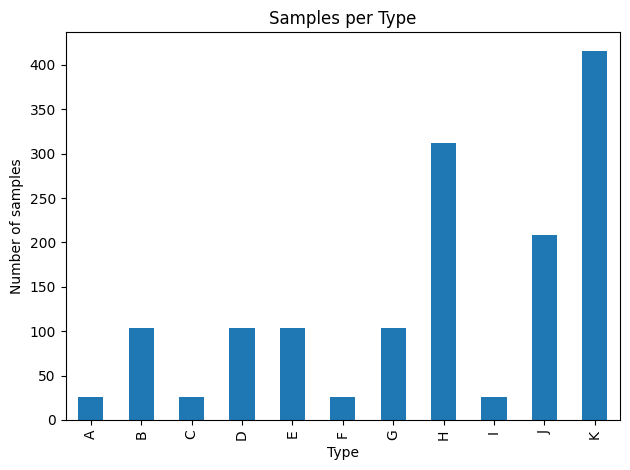

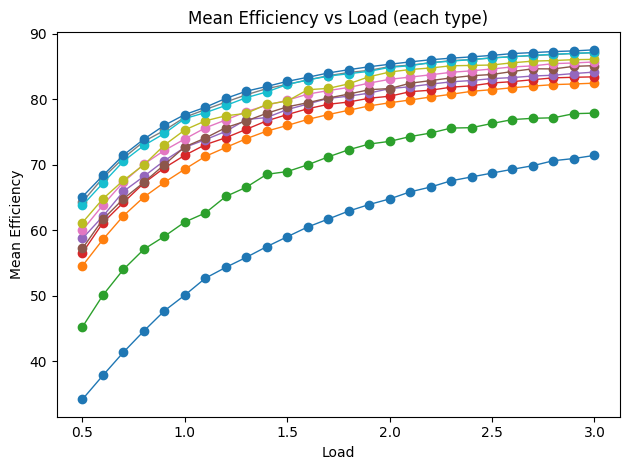

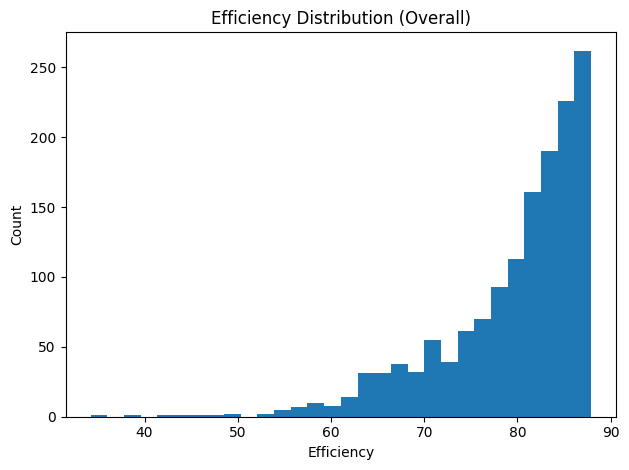


Mean pivot shape: (11, 26)
Std pivot shape: (7, 26)

Saved: wpt_mean_pivot.csv, wpt_std_pivot.csv, wpt_condition_stats.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Step 1 — Load dataset + Basic checks
# =========================
PATH = "WPT.csv"  # change this path if needed
df = pd.read_csv(PATH)

print("Original columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head())

# Rename columns to English for readability
rename_map = {
    "種類": "type",
    "負載": "load",
    "效率": "efficiency",
}
df = df.rename(columns=rename_map)

# Enforce dtypes (protect against parsing issues)
df["type"] = df["type"].astype(str)
df["load"] = pd.to_numeric(df["load"], errors="coerce")
df["efficiency"] = pd.to_numeric(df["efficiency"], errors="coerce")

# Check missing values / parsing errors
print("\nMissing values (after coercion):\n", df.isna().sum())

# Drop rows with missing key fields (safe default for EDA)
df = df.dropna(subset=["type", "load", "efficiency"]).reset_index(drop=True)

print("\nRanges:")
print("load min/max:", df["load"].min(), df["load"].max())
print("efficiency min/max:", df["efficiency"].min(), df["efficiency"].max())

# =========================
# Step 1 — Summary tables
# =========================
# Count samples per type
type_counts = df["type"].value_counts().sort_index()
print("\nCounts by type:\n", type_counts)

# Count samples per load (overall)
load_counts = df["load"].value_counts().sort_index()
print("\nCounts by load:\n", load_counts)

# Count repeats per condition (type, load)
cond_counts = df.groupby(["type", "load"]).size().rename("n").reset_index()
print("\nCondition count summary:")
print("Number of conditions:", cond_counts.shape[0])
print("min repeats:", cond_counts["n"].min(), "max repeats:", cond_counts["n"].max())
print(cond_counts.head())

# Per-condition statistics (useful later for Gaussian baseline generation)
cond_stats = (
    df.groupby(["type", "load"])["efficiency"]
      .agg(["count", "mean", "std", "min", "max"])
      .reset_index()
)
print("\nCondition stats (head):")
print(cond_stats.head())

# =========================
# Step 1 — Plots
# =========================
# Plot 1: sample count per type
plt.figure()
type_counts.plot(kind="bar")
plt.xlabel("Type")
plt.ylabel("Number of samples")
plt.title("Samples per Type")
plt.tight_layout()
plt.show()

# Plot 2: mean efficiency vs load for each type
plt.figure()
for t in sorted(df["type"].unique()):
    sub = df[df["type"] == t].groupby("load")["efficiency"].mean()
    plt.plot(sub.index, sub.values, marker="o", linewidth=1, label=t)

plt.xlabel("Load")
plt.ylabel("Mean Efficiency")
plt.title("Mean Efficiency vs Load (each type)")
plt.tight_layout()
# If the plot is too crowded, uncomment legend or remove it
# plt.legend(ncol=3, fontsize=8)
plt.show()

# Plot 3: efficiency distribution (overall)
plt.figure()
plt.hist(df["efficiency"], bins=30)
plt.xlabel("Efficiency")
plt.ylabel("Count")
plt.title("Efficiency Distribution (Overall)")
plt.tight_layout()
plt.show()

# =========================
# Optional — Pivot tables (mean/std) for reporting
# =========================
mean_pivot = df.pivot_table(index="type", columns="load", values="efficiency", aggfunc="mean")
std_pivot  = df.pivot_table(index="type", columns="load", values="efficiency", aggfunc="std")

print("\nMean pivot shape:", mean_pivot.shape)
print("Std pivot shape:", std_pivot.shape)

# Save outputs (optional)
mean_pivot.to_csv("wpt_mean_pivot.csv", encoding="utf-8-sig")
std_pivot.to_csv("wpt_std_pivot.csv", encoding="utf-8-sig")
cond_stats.to_csv("wpt_condition_stats.csv", index=False, encoding="utf-8-sig")

print("\nSaved: wpt_mean_pivot.csv, wpt_std_pivot.csv, wpt_condition_stats.csv")